In [89]:
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

from glob import glob
import os

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [90]:
corpora = pd.read_parquet("../corpora/GeneratedCorpus/corpora_v3.parquet")
corpora = corpora.reset_index(names='text_id')

In [91]:
causal_sliding = pd.DataFrame()

# Carregando zero-shot causal_sliding
zs_cs_folder = "../results_grammar_and_lexical/results"
files = glob(zs_cs_folder + "/*")

for file in files:
    temp = pd.read_csv(file)
    temp["knowledge"] = "Zero-Shot"
    causal_sliding = pd.concat([causal_sliding, temp])
    
    
models = os.listdir("../outputs_hatebr_lora/results/")
for model in models:
    # Carregando fine-tuning causal_sliding
    temp = pd.read_csv(f"../outputs_hatebr_lora/results/{model}/hatebr_eval_causal_sliding.csv")
    temp["model"] = model
    temp["knowledge"] = "Fine-Tuning"
    causal_sliding = pd.concat([causal_sliding, temp])
        
causal_sliding = pd.merge(causal_sliding, corpora)

model_order = [
    "Manaca",
    "Tucano-2b4",
    "Cabrita",
    "Sabia 7B",
    "Llama3.1",
    "Qwen3.5-9B",
    "Gemma4-12B",
]

causal_sliding["model"] = pd.Categorical(
    causal_sliding["model"],
    categories=model_order,
    ordered=True
)

causal_sliding = causal_sliding[causal_sliding["language"].isin(["INGLÊS", "ESPANHOL", "PB NATIVO"])]
causal_sliding = causal_sliding[~causal_sliding["scenario"].isin(["GRAMMAR SWAP", "GRAMMAR SWAP v2"])]

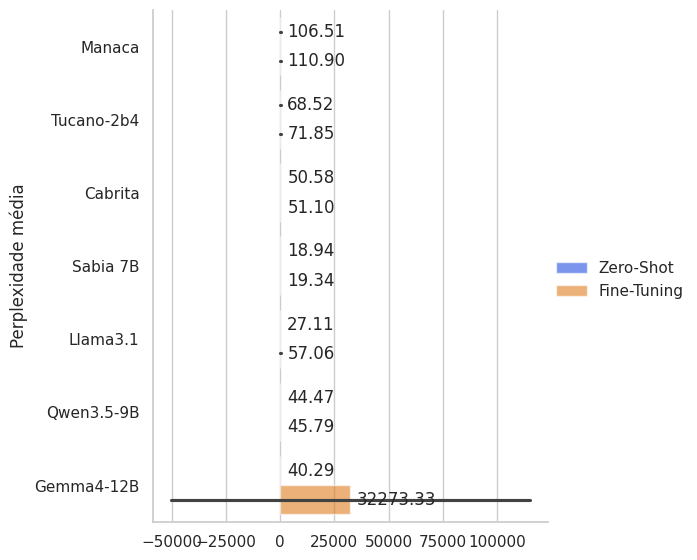

In [92]:
g = sns.catplot(
    data=causal_sliding,
    kind="bar",
    y="model", x="ppl", orient="h", 
    hue="knowledge",
    estimator="mean", errorbar="sd", 
    palette="bright", alpha=.6, height=6, 
)

g.set_axis_labels("", "Perplexidade média")
g.legend.set_title("")

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=5)

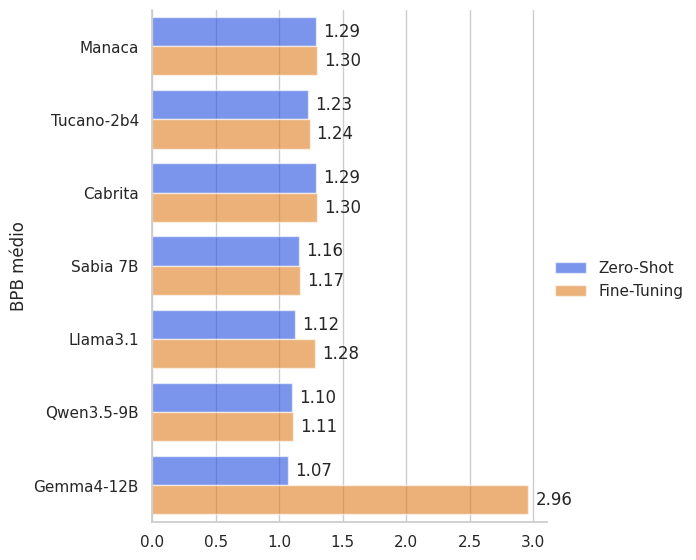

In [94]:
g = sns.catplot(
    data=causal_sliding,
    kind="bar",
    y="model", x="bpb", orient="h", 
    hue="knowledge",
    estimator="mean", errorbar=None, 
    palette="bright", alpha=.6, height=6, 
)

g.set_axis_labels("", "BPB médio")

g.legend.set_title("")

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=5)

In [43]:
causal_sliding.columns

Index(['text_id', 'num_words', 'num_bytes', 'num_tokens', 'tokens_per_word',
       'average_nll', 'total_nll', 'ppl', 'bpb', 'model', 'knowledge',
       'scenario', 'language', 'task', 'task_type', 'text'],
      dtype='str')

In [42]:
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(causal_sliding.groupby(["model", "knowledge", "scenario"])["ppl"].mean())


model       knowledge    scenario       
Manaca      Fine-Tuning  GRAMMAR SWAP v3       43.16
                         LEXICAL SWAP          40.50
                         PB CORRUPTED         134.21
                         PB NATIVO             34.02
                         PB PERMUTED          616.18
                         TRANSLATION           23.21
            Zero-Shot    GRAMMAR SWAP v3       42.51
                         LEXICAL SWAP          39.30
                         PB CORRUPTED         131.31
                         PB NATIVO             32.93
                         PB PERMUTED          585.13
                         TRANSLATION           22.79
Tucano-2b4  Fine-Tuning  GRAMMAR SWAP v3       35.54
                         LEXICAL SWAP          18.95
                         PB CORRUPTED          99.96
                         PB NATIVO             26.04
                         PB PERMUTED          387.71
                         TRANSLATION           11.96
     

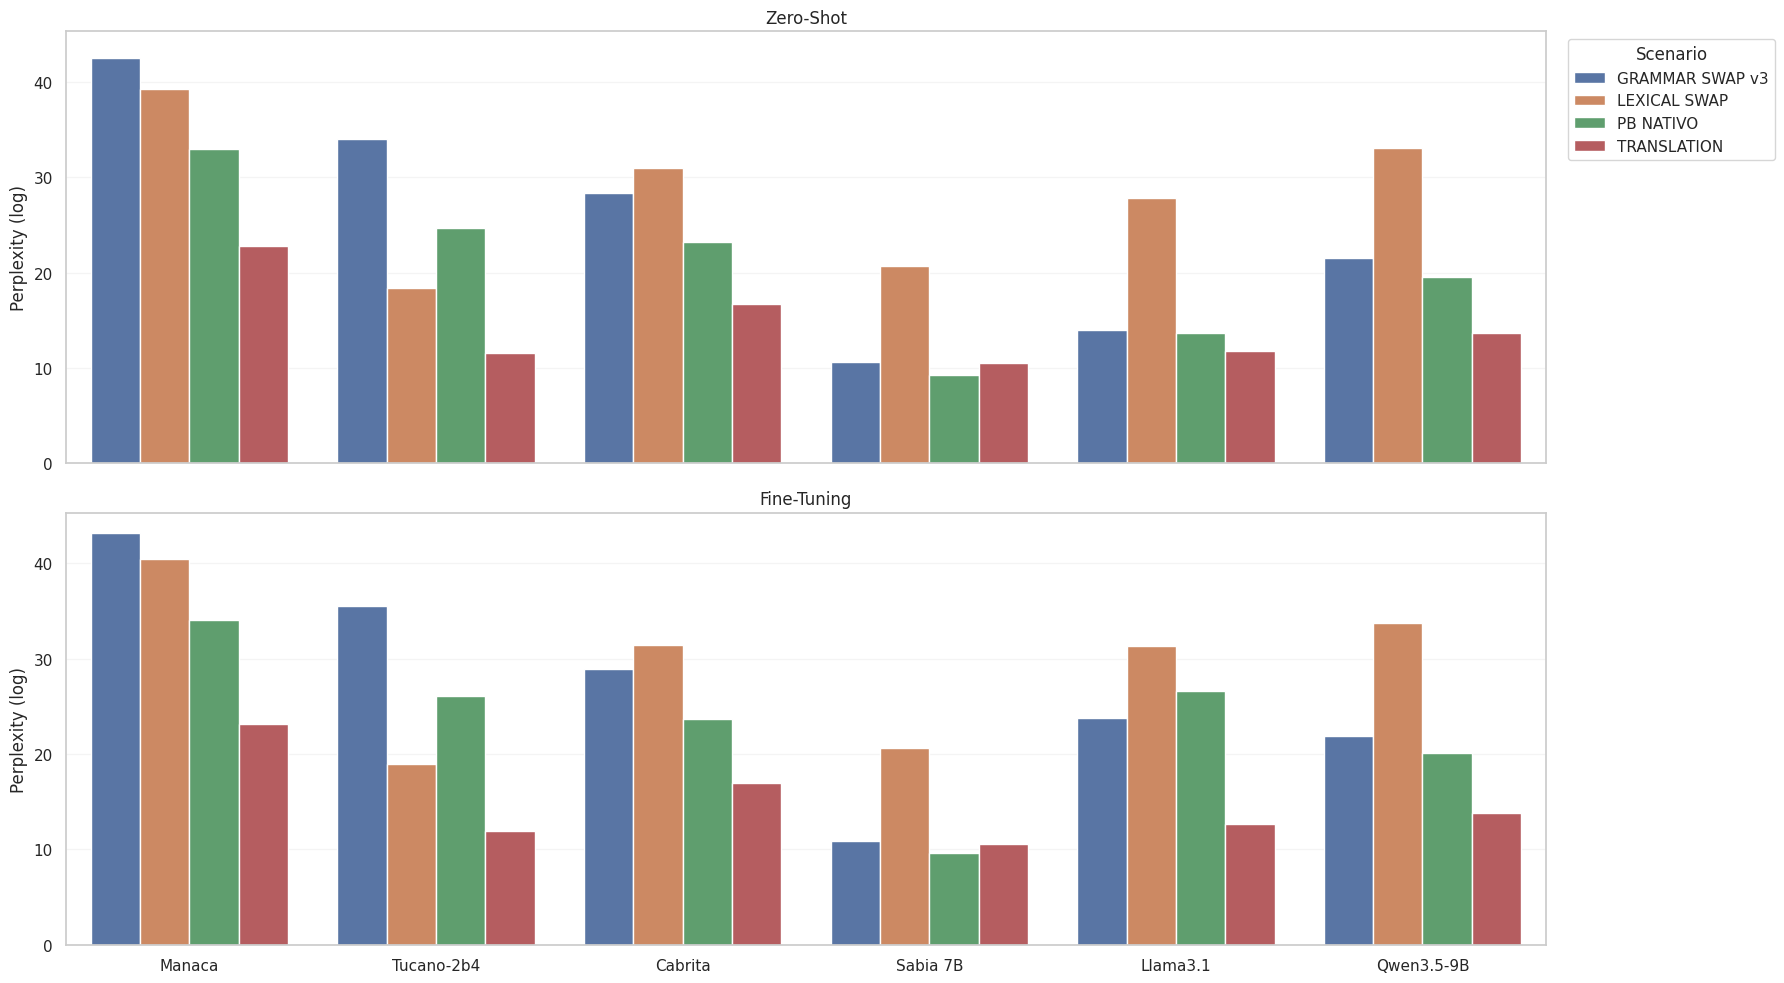

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

metrica = "ppl"

df = (
    causal_sliding
    .groupby(["model", "knowledge", "scenario"], as_index=False)[metrica]
    .mean()
)

df = df[~df["model"].isin(["Gemma4-12B"])]
df = df[~df["scenario"].isin(["PB CORRUPTED", "PB PERMUTED"])]

model_order = df["model"].unique()
scenario_order = df["scenario"].unique()

fig, axes = plt.subplots(
    2, 1,
    figsize=(18, 10),
    sharex=True,
    sharey=True
)

for ax, knowledge in zip(axes, ["Zero-Shot", "Fine-Tuning"]):
    sns.barplot(
        data=df[df["knowledge"] == knowledge],
        x="model",
        y=metrica,
        hue="scenario",
        order=model_order,
        hue_order=scenario_order,
        ax=ax
    )

    # ax.set_yscale("log")
    ax.set_title(knowledge)
    ax.set_ylabel("Perplexity (log)")
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=.2)

axes[0].legend(
    title="Scenario",
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)
axes[1].legend_.remove()

plt.tight_layout()
plt.show()

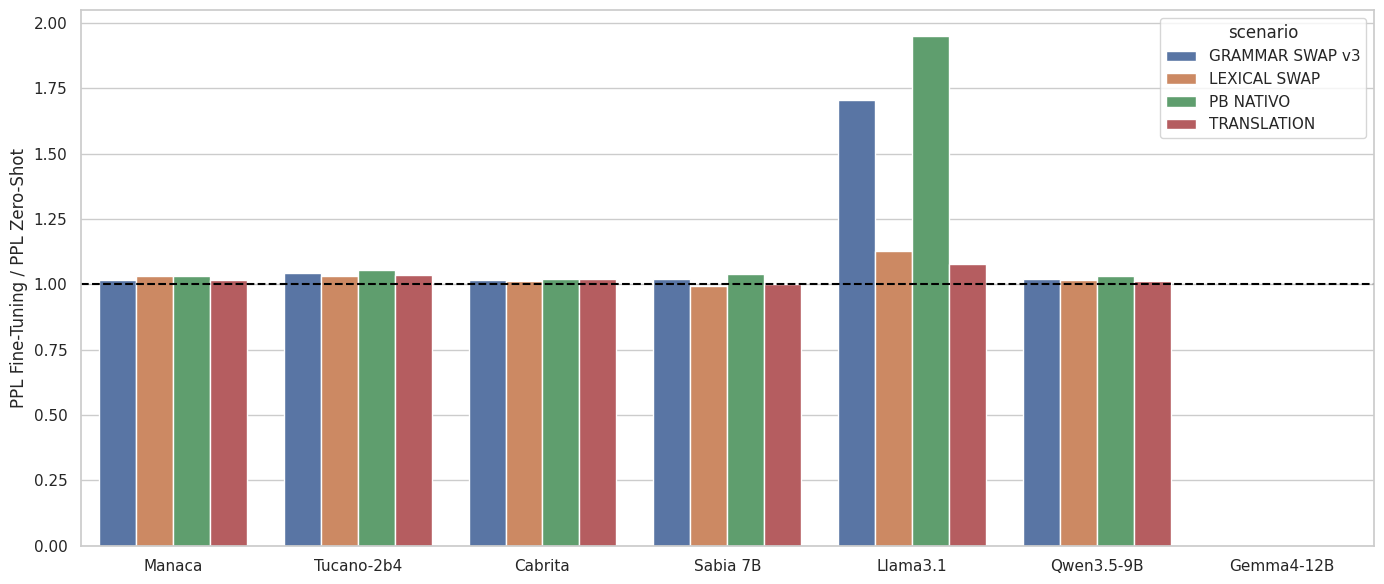

In [65]:
ratio = (
    df.pivot(
        index=["model", "scenario"],
        columns="knowledge",
        values=metrica
    )
    .reset_index()
)

ratio["ratio"] = ratio["Fine-Tuning"] / ratio["Zero-Shot"]

plt.figure(figsize=(14, 6))

sns.barplot(
    data=ratio,
    x="model",
    y="ratio",
    hue="scenario"
)

plt.axhline(1, color="black", linestyle="--")
#plt.yscale("log")
plt.ylabel("PPL Fine-Tuning / PPL Zero-Shot")
plt.xlabel("")
plt.tight_layout()
plt.show()

# HateBR

In [67]:
import json

In [ ]:
models = os.listdir("../outputs_hatebr_lora/results/")

hatebr = dict()
for model in models:
    # Carregando fine-tuning causal_sliding
    hatebr[model] = dict()
    
    with open(f"../outputs_hatebr_lora/results/{model}/hatebr_zero_shot_metrics.json") as f:
        hatebr[model]["zero-shot"] = json.load(f)
    
    with open(f"../outputs_hatebr_lora/results/{model}/hatebr_finetuned_metrics.json") as f:
            hatebr[model]["fine-tuning"] = json.load(f)
    

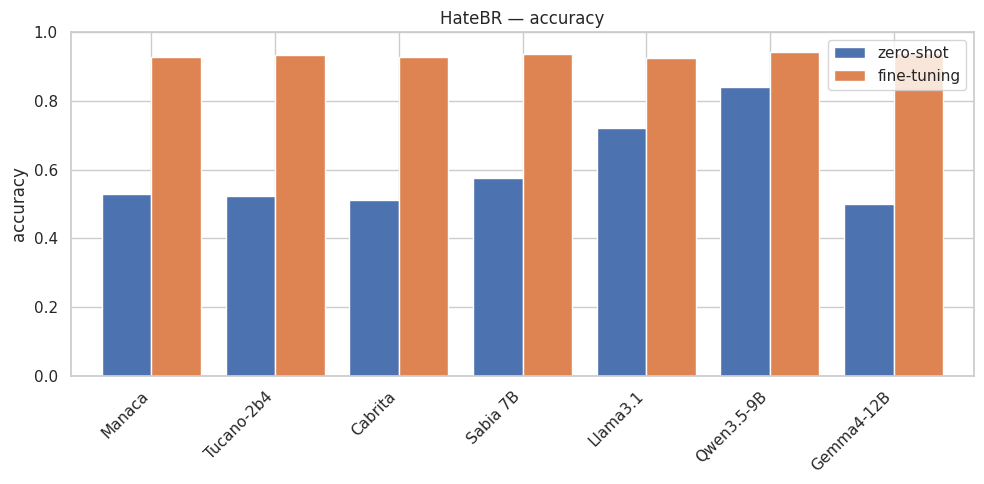

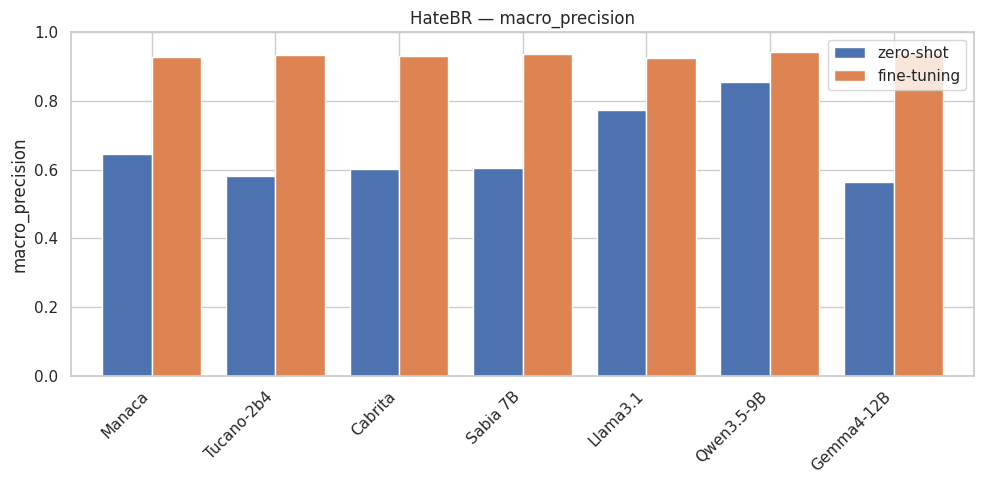

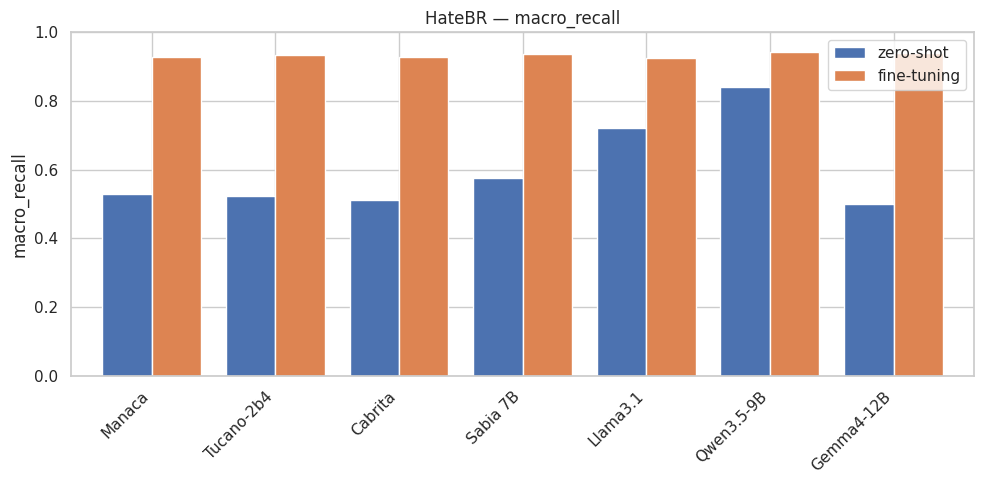

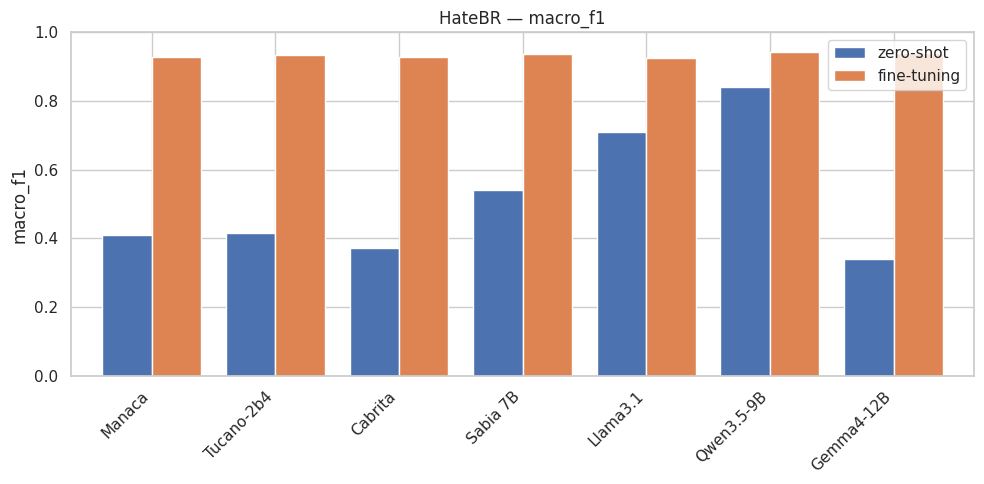

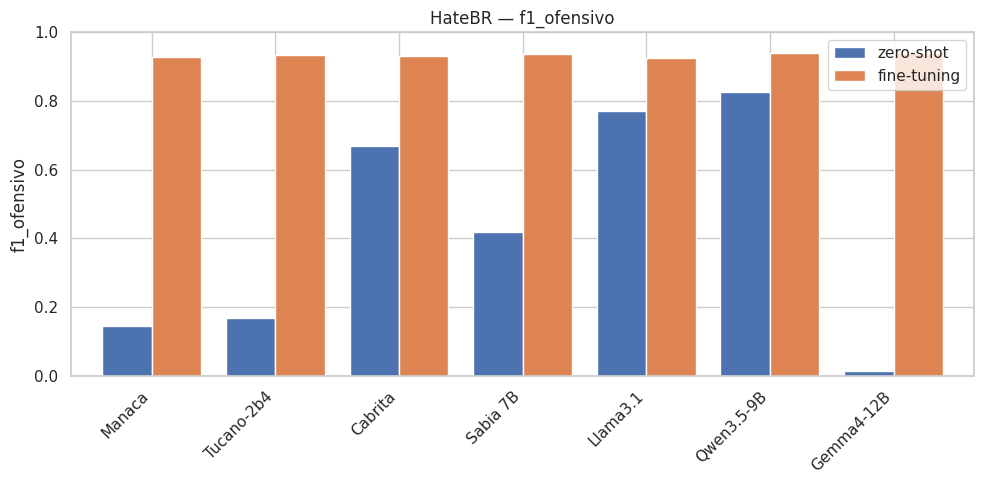

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["accuracy", "macro_precision", "macro_recall", "macro_f1", "f1_ofensivo"]

rows = []
for model, results in hatebr.items():
    for setup in ["fine-tuning", "zero-shot"]:
        rows.append({
            "model": model,
            "setup": setup,
            **{m: results[setup][m] for m in metrics}
        })

df = pd.DataFrame(rows)

model_order = [
    "Manaca",
    "Tucano-2b4",
    "Cabrita",
    "Sabia 7B",
    "Llama3.1",
    "Qwen3.5-9B",
    "Gemma4-12B",
]

df["model"] = pd.Categorical(
    df["model"],
    categories=model_order,
    ordered=True
)


for metric in metrics:
    pivot = df.pivot(index="model", columns="setup", values=metric)
    pivot = pivot[["zero-shot", "fine-tuning"]]

    ax = pivot.plot(
        kind="bar",
        figsize=(10, 5),
        ylim=(0, 1),
        width=0.8
    )

    ax.set_title(f"HateBR — {metric}")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.legend(title="")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

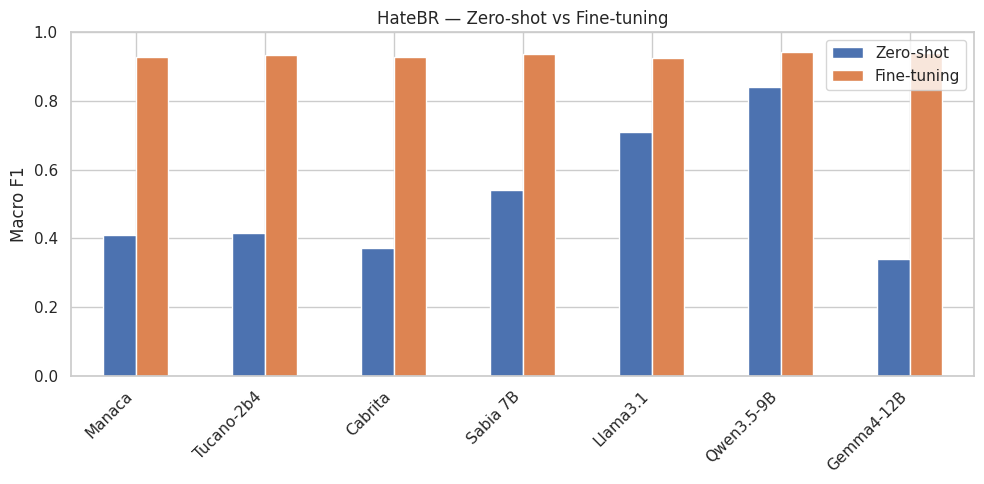

In [83]:
df_f1 = pd.DataFrame({
    model: {
        "Zero-shot": r["zero-shot"]["macro_f1"],
        "Fine-tuning": r["fine-tuning"]["macro_f1"]
    }
    for model, r in hatebr.items()
}).T



model_order = [
    "Manaca",
    "Tucano-2b4",
    "Cabrita",
    "Sabia 7B",
    "Llama3.1",
    "Qwen3.5-9B",
    "Gemma4-12B",
]

# df_f1: modelos estão no índice
df_f1 = df_f1.reindex(model_order)


ax = df_f1.plot.bar(figsize=(10, 5), ylim=(0, 1))

ax.set_title("HateBR — Zero-shot vs Fine-tuning")
ax.set_ylabel("Macro F1")
ax.set_xlabel("")
ax.legend(title="")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [86]:
import pandas as pd

metrics = ["accuracy", "macro_precision", "macro_recall", "macro_f1", "f1_ofensivo"]

rows = []
for model, results in hatebr.items():
    for metric in metrics:
        zero = results["zero-shot"][metric]
        ft = results["fine-tuning"][metric]

        rows.append({
            "Modelo": model,
            "Métrica": metric,
            "Zero-shot": zero,
            "Fine-tuning": ft,
            "Ganho (%)": (ft - zero) / zero * 100 if zero != 0 else float("nan")
        })

df_results = pd.DataFrame(rows)

df_results["Modelo"] = pd.Categorical(
    df_results["Modelo"],
    categories=model_order,
    ordered=True
)

df_results = df_results.sort_values(
    ["Modelo"]
)

display(
    df_results.style
    .format({
        "Zero-shot": "{:.4f}",
        "Fine-tuning": "{:.4f}",
        "Ganho (%)": "{:+.2f}%"
    })
    # .background_gradient(subset=["Ganho (%)"], cmap="RdYlGn")
)

,Modelo,Métrica,Zero-shot,Fine-tuning,Ganho (%)
24,Manaca,f1_ofensivo,0.1451,0.9294,+540.65%
22,Manaca,macro_recall,0.5286,0.9293,+75.81%
21,Manaca,macro_precision,0.6464,0.9293,+43.76%
20,Manaca,accuracy,0.5286,0.9293,+75.81%
23,Manaca,macro_f1,0.4098,0.9293,+126.76%
14,Tucano-2b4,f1_ofensivo,0.1669,0.9345,+459.99%
13,Tucano-2b4,macro_f1,0.4159,0.9343,+124.62%
11,Tucano-2b4,macro_precision,0.5812,0.9343,+60.75%
10,Tucano-2b4,accuracy,0.5221,0.9343,+78.93%
12,Tucano-2b4,macro_recall,0.5221,0.9343,+78.93%


In [95]:
display(
    df_results[df_results["Métrica"] == "accuracy"]
    #.sort_values("Ganho (%)", ascending=False)
    .style.format({
        "Zero-shot": "{:.4f}",
        "Fine-tuning": "{:.4f}",
        "Ganho (%)": "{:+.2f}%"
    })
)

,Modelo,Métrica,Zero-shot,Fine-tuning,Ganho (%)
20,Manaca,accuracy,0.5286,0.9293,+75.81%
10,Tucano-2b4,accuracy,0.5221,0.9343,+78.93%
30,Cabrita,accuracy,0.5114,0.9293,+81.70%
5,Sabia 7B,accuracy,0.5750,0.9371,+62.98%
25,Llama3.1,accuracy,0.7221,0.9243,+27.99%
15,Qwen3.5-9B,accuracy,0.8421,0.9414,+11.79%
0,Gemma4-12B,accuracy,0.5014,0.9407,+87.61%
